In [20]:
import json
import os
import logging
import numpy as np
import requests
from PIL import Image
import scipy.stats
import matplotlib.pyplot as plt
import sys
import plotly.express as px

# pandas
import pandas as pd
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
# check环境
print(sys.executable)
print(sys.version)

/nfs_beijing/kubeflow-user/yujie/.conda/envs/icey/bin/python
3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]


# load data

In [21]:
# load dms result of stability model
data = pd.read_csv('all_single_mut.csv', index_col=0)
stability_pred = pd.read_csv('all_single_mut_stability_input.pred.csv').set_index('unique_id')['pred'].to_dict()
data['stability_ddg'] = data['unique_id'].apply(lambda x: stability_pred[x])
data['mut_posis'] = data['pdb_mutation'].apply(lambda x: x.split(','))
data['posi'] = data['pdb_mutation'].apply(lambda x: int(x[2:-1]))
data['mt'] = data['pdb_mutation'].apply(lambda x: x[-1])
data['wt'] = data['pdb_mutation'].apply(lambda x: x[0])
_data = data.groupby(['posi']).apply(
    lambda x: (x['stability_ddg'].mean() - x['stability_ddg'].std()) 
).rename('ddg_std').reset_index()

In [23]:
# 1. load dms result of stability model
# 2. sliding window average
def sliding_window_average(data, window_size):
    if window_size <= 0:
        raise ValueError("Window size must be positive")
    if len(data) < window_size:
        raise ValueError("Data length must be greater than or equal to window size")

    window = np.ones(window_size) / window_size
    result = np.convolve(data, window, mode='same')
    
    return result
    
_data['ddg_std'] = sliding_window_average(_data['ddg_std'], 7)
# 3. threshold filter, keep points with ddg_std >= -0.45
_data['c'] = _data['ddg_std'] < -0.45

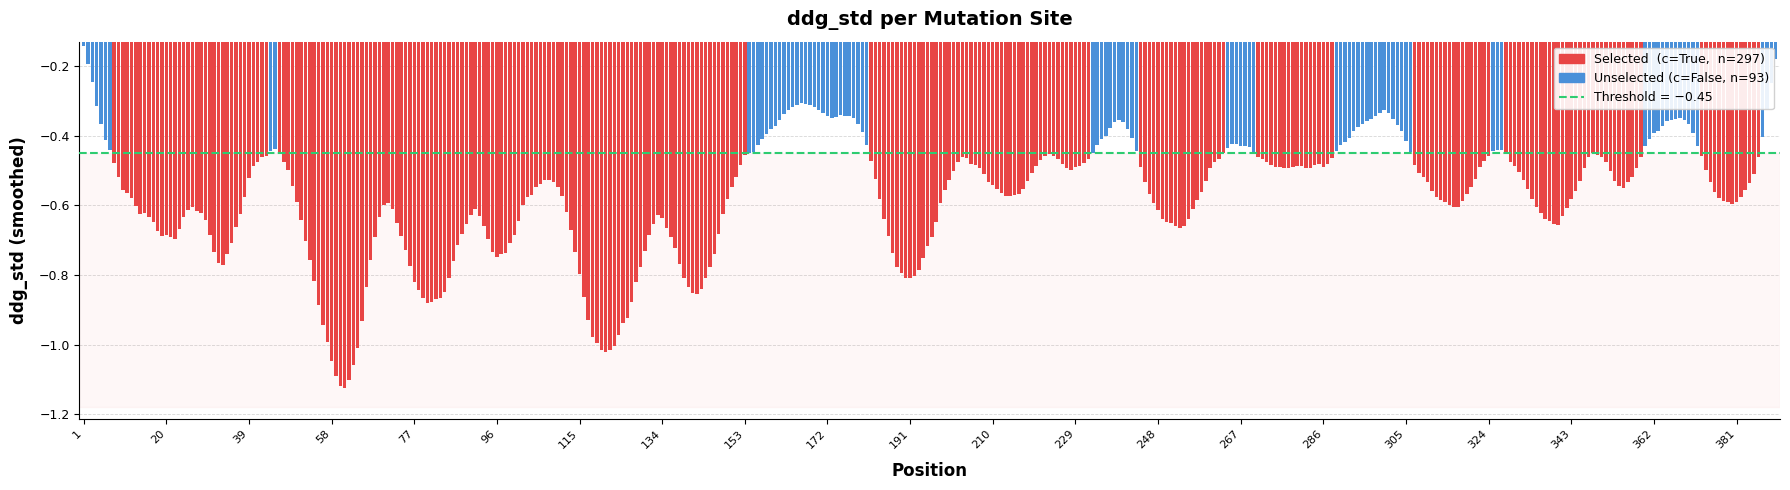

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(18, 5))

# ── Color mapping ──────────────────────────────────────────────────────────
colors = ['#E84545' if c else '#4A90D9' for c in _data['c']]

# ── Bar plot ───────────────────────────────────────────────────────────────
bars = ax.bar(
    _data['posi'], _data['ddg_std'],
    color=colors, width=0.8, linewidth=0, zorder=2
)

# ── Threshold line ─────────────────────────────────────────────────────────
ax.axhline(-0.45, color='#2ECC71', linewidth=1.5,
           linestyle='--', zorder=3, label='Threshold = −0.45')

# ── Zero baseline ──────────────────────────────────────────────────────────
ax.axhline(0, color='#333333', linewidth=0.8, zorder=3)

# ── Shaded region below threshold ─────────────────────────────────────────
ax.axhspan(ax.get_ylim()[0], -0.45, color='#E84545', alpha=0.04, zorder=1)

# ── Grid ───────────────────────────────────────────────────────────────────
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# ── Labels & title ─────────────────────────────────────────────────────────
ax.set_xlabel('Position', fontsize=12, fontweight='bold', labelpad=8)
ax.set_ylabel('ddg_std (smoothed)', fontsize=12, fontweight='bold', labelpad=8)
ax.set_title('ddg_std per Mutation Site', fontsize=14, fontweight='bold', pad=12)

# ── X-axis ticks: show every N positions to avoid crowding ────────────────
n_ticks = 20
tick_step = max(1, len(_data) // n_ticks)
tick_positions = _data['posi'].values[::tick_step]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_positions, fontsize=8, rotation=45, ha='right')
ax.tick_params(axis='y', labelsize=9)

# ── X limits: no padding ──────────────────────────────────────────────────
ax.set_xlim(_data['posi'].min() - 1, _data['posi'].max() + 1)

# ── Y limits: add breathing room ──────────────────────────────────────────
y_min = _data['ddg_std'].min()
y_max = _data['ddg_std'].max()
ax.set_ylim(y_min - abs(y_min) * 0.08, y_max + abs(y_max) * 0.08)

# ── Legend ─────────────────────────────────────────────────────────────────
patch_selected   = mpatches.Patch(color='#E84545', label=f'Selected  (c=True,  n={_data["c"].sum()})')
patch_unselected = mpatches.Patch(color='#4A90D9', label=f'Unselected (c=False, n={(~_data["c"]).sum()})')
ax.legend(handles=[patch_selected, patch_unselected,
                   plt.Line2D([0], [0], color='#2ECC71', linewidth=1.5,
                              linestyle='--', label='Threshold = −0.45')],
          fontsize=9, framealpha=0.9, loc='upper right')

# ── Spine styling ──────────────────────────────────────────────────────────
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

plt.tight_layout()
plt.show()


# Parameter Sensitivity

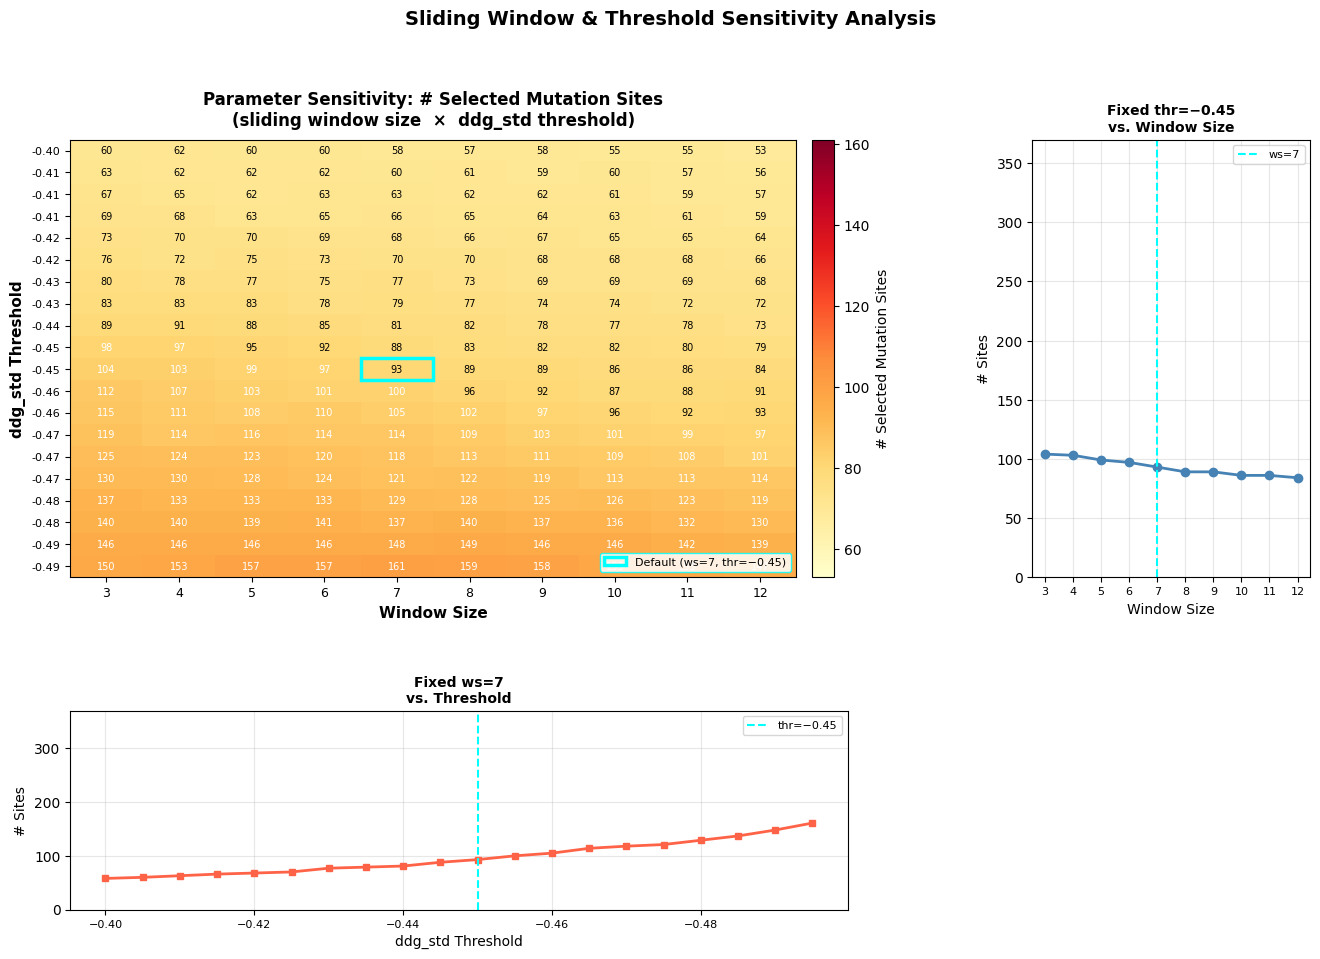

Done.


In [19]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

# ── 3. Parameter Grid ─────────────────────────────────────────────────────
window_sizes = np.arange(3, 13, 1)                          # window sizes: 3~12
thresholds   = np.round(np.arange(-0.4, -0.5, -0.005), 3)  # thresholds: -0.40 ~ -0.50

# ── 4. Sensitivity Matrix: number of selected mutation sites ──────────────
count_matrix = np.zeros((len(thresholds), len(window_sizes)), dtype=int)

for j, ws in enumerate(window_sizes):
    smoothed = sliding_window_average(_data['ddg_std'].values, ws)
    for i, thr in enumerate(thresholds):
        count_matrix[i, j] = int((smoothed >= thr).sum())

# ── 5. Plotting ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = GridSpec(2, 2, figure=fig,
               width_ratios=[2.8, 1], height_ratios=[2.2, 1],
               hspace=0.42, wspace=0.35)

ax_heat = fig.add_subplot(gs[0, 0])   # main heatmap
ax_ws   = fig.add_subplot(gs[0, 1])   # marginal: window size
ax_thr  = fig.add_subplot(gs[1, 0])   # marginal: threshold

# ── 5a. Heatmap ───────────────────────────────────────────────────────────
cmap = plt.cm.YlOrRd
im = ax_heat.imshow(
    count_matrix, aspect='auto', cmap=cmap,
    origin='upper', interpolation='nearest',
    vmin=0, vmax=370
)

cb = fig.colorbar(im, ax=ax_heat, pad=0.02, fraction=0.046)
cb.set_label('# Selected Mutation Sites', fontsize=10)

ax_heat.set_xticks(range(len(window_sizes)))
ax_heat.set_xticklabels(window_sizes, fontsize=9)
ax_heat.set_yticks(range(len(thresholds)))
ax_heat.set_yticklabels([f'{t:.2f}' for t in thresholds], fontsize=8)
ax_heat.set_xlabel('Window Size',       fontsize=11, fontweight='bold')
ax_heat.set_ylabel('ddg_std Threshold', fontsize=11, fontweight='bold')
ax_heat.set_title(
    'Parameter Sensitivity: # Selected Mutation Sites\n'
    '(sliding window size × ddg_std threshold)',
    fontsize=12, fontweight='bold', pad=10
)

# Annotate each cell with its count
for i in range(len(thresholds)):
    for j in range(len(window_sizes)):
        v   = count_matrix[i, j]
        col = 'white' if v > count_matrix.max() * 0.6 else 'black'
        ax_heat.text(j, i, str(v), ha='center', va='center',
                     fontsize=7, color=col)

# Mark default parameter position (window=7, threshold=-0.45)
default_ws_idx  = list(window_sizes).index(7)
default_thr_idx = np.argmin(np.abs(thresholds - (-0.45)))
ax_heat.add_patch(plt.Rectangle(
    (default_ws_idx - 0.5, default_thr_idx - 0.5), 1, 1,
    fill=False, edgecolor='cyan', linewidth=2.5,
    label='Default (ws=7, thr=−0.45)'
))
ax_heat.legend(loc='lower right', fontsize=8, framealpha=0.85, edgecolor='cyan')

# ── 5b. Marginal: fixed threshold=-0.45, sweep window size ───────────────
counts_by_ws = count_matrix[default_thr_idx, :]
ax_ws.plot(window_sizes, counts_by_ws, 'o-', color='steelblue',
           linewidth=2, markersize=6)
ax_ws.axvline(7, color='cyan', linestyle='--', linewidth=1.5, label='ws=7')
ax_ws.set_xlabel('Window Size', fontsize=10)
ax_ws.set_ylabel('# Sites',     fontsize=10)
ax_ws.set_title('Fixed thr=−0.45\nvs. Window Size', fontsize=10, fontweight='bold')
ax_ws.legend(fontsize=8)
ax_ws.grid(True, alpha=0.3)
ax_ws.set_xticks(window_sizes)
ax_ws.tick_params(axis='x', labelsize=8)
ax_ws.set_ylim(0, 370)

# ── 5c. Marginal: fixed window=7, sweep threshold ────────────────────────
counts_by_thr = count_matrix[:, default_ws_idx]
ax_thr.plot(thresholds, counts_by_thr, 's-', color='tomato',
            linewidth=2, markersize=5)
ax_thr.axvline(-0.45, color='cyan', linestyle='--', linewidth=1.5, label='thr=−0.45')
ax_thr.set_xlabel('ddg_std Threshold', fontsize=10)
ax_thr.set_ylabel('# Sites',           fontsize=10)
ax_thr.set_title('Fixed ws=7\nvs. Threshold', fontsize=10, fontweight='bold')
ax_thr.legend(fontsize=8)
ax_thr.grid(True, alpha=0.3)
ax_thr.invert_xaxis()
ax_thr.tick_params(axis='x', labelsize=8)
ax_thr.set_ylim(0, 370)

fig.suptitle('Sliding Window & Threshold Sensitivity Analysis',
             fontsize=14, fontweight='bold', y=1.01)
plt.show()
print("Done.")